# Day 7: Astronomy Reflection And Model Interpretation

Day 7 connects the Week 2 regression work back to the Gaia astronomy question.

The important idea is that a model can be numerically useful while still being physically incomplete. A straight-line regression can capture the broad relationship between color and absolute magnitude, but it cannot fully represent the curved main sequence or separate stellar populations in the Hertzsprung-Russell diagram.

Residuals are useful clues. Large residuals can point to stars from different populations, noisy measurements, or assumptions that the model is too simple to handle.

## 1. Imports

We will train several scikit-learn linear regression models using the same train/test split so their metrics are directly comparable.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.colors import TwoSlopeNorm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

## 2. Load The Day 3 Feature Dataset

Day 3 saved the modeling table with the target `abs_g_mag` and candidate features. Day 7 uses that table so the final comparison starts from the same cleaned data and target definition as the previous notebooks.

In [2]:
feature_candidates = [
    Path("../data/processed/gaia_day3_feature_selection.csv"),
    Path("data/processed/gaia_day3_feature_selection.csv"),
    Path("gaia-explorer/data/processed/gaia_day3_feature_selection.csv"),
]

FEATURE_PATH = next((path for path in feature_candidates if path.exists()), None)

if FEATURE_PATH is None:
    searched = "\n".join(str(path) for path in feature_candidates)
    raise FileNotFoundError(
        "Could not find Day 3 feature data. Run day_03_feature_selection.ipynb first.\n"
        f"Searched:\n{searched}"
    )

feature_df = pd.read_csv(FEATURE_PATH)
print(f"Loaded Day 3 feature data from: {FEATURE_PATH}")
print("Feature dataset shape:", feature_df.shape)
feature_df.head()

Loaded Day 3 feature data from: ../data/processed/gaia_day3_feature_selection.csv
Feature dataset shape: (2413, 6)


,source_id,abs_g_mag,bp_rp,parallax_snr,ra,dec
0,137338902210136064,7.400051,1.725426,9.333179,45.039785,35.288983
1,137341135593106176,4.617324,0.926100,25.084431,45.141976,35.385239
2,137342028946292224,10.602563,3.103573,10.161903,45.154690,35.461248
3,137345052603307136,6.335299,1.242174,18.125324,44.952444,35.304778
4,137346220834302080,6.432088,1.309051,33.519712,44.944379,35.374441


## 3. Review Column Roles

These columns do not all mean the same thing scientifically.

- `bp_rp` is the main physical predictor here. It is Gaia color: smaller values are bluer/hotter, larger values are redder/cooler.
- `parallax_snr` is mostly a data-quality diagnostic. It tells us how reliable the parallax measurement is. It is useful for analysis, but it is not a clean physical brightness feature because it is derived from parallax, and parallax is also used to compute `abs_g_mag`.
- `ra` and `dec` are sky coordinates. They are not intrinsic brightness features. If they help, it may reflect sample selection, sky coverage, or local structure in the sample rather than stellar physics.
- `abs_g_mag` is the target. Lower absolute magnitude means intrinsically brighter. Higher absolute magnitude means fainter.

In [3]:
required_columns = ["source_id", "abs_g_mag", "bp_rp", "parallax_snr", "ra", "dec"]
missing_required_columns = [col for col in required_columns if col not in feature_df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

modeling_df = feature_df.dropna(subset=required_columns).copy()

column_role_table = pd.DataFrame(
    [
        {
            "column": "bp_rp",
            "role": "physical predictor",
            "interpretation": "Gaia color; lower is bluer/hotter, higher is redder/cooler.",
        },
        {
            "column": "parallax_snr",
            "role": "diagnostic predictor",
            "interpretation": "Parallax measurement reliability; higher means more reliable parallax.",
        },
        {
            "column": "ra",
            "role": "sky-position predictor",
            "interpretation": "Right ascension; useful for detecting sample effects, not intrinsic brightness.",
        },
        {
            "column": "dec",
            "role": "sky-position predictor",
            "interpretation": "Declination; useful for detecting sample effects, not intrinsic brightness.",
        },
        {
            "column": "abs_g_mag",
            "role": "target",
            "interpretation": "Absolute Gaia G magnitude; lower values are brighter.",
        },
    ]
)

print("Rows available for Day 7:", len(modeling_df))
column_role_table

Rows available for Day 7: 2413


,column,role,interpretation
0,bp_rp,physical predictor,"Gaia color; lower is bluer/hotter, higher is r..."
1,parallax_snr,diagnostic predictor,Parallax measurement reliability; higher means...
2,ra,sky-position predictor,Right ascension; useful for detecting sample e...
3,dec,sky-position predictor,Declination; useful for detecting sample effec...
4,abs_g_mag,target,Absolute Gaia G magnitude; lower values are br...


## 4. Define The Three Feature Sets

The Day 7 comparison asks whether adding diagnostic and sky-position features changes predictive performance.

The feature sets are:

1. `bp_rp` only: the simplest physically meaningful model.
2. `bp_rp + parallax_snr`: tests whether measurement quality relates to residuals.
3. `bp_rp + parallax_snr + ra + dec`: tests whether measurement quality plus sky position changes the fit.

Use the second and third models carefully. They can improve metrics slightly without giving a cleaner physical explanation of stellar luminosity.

In [4]:
feature_sets = {
    "bp_rp only": ["bp_rp"],
    "bp_rp + parallax_snr": ["bp_rp", "parallax_snr"],
    "bp_rp + parallax_snr + ra + dec": ["bp_rp", "parallax_snr", "ra", "dec"],
}

target_column = "abs_g_mag"
all_feature_columns = ["bp_rp", "parallax_snr", "ra", "dec"]
metadata_columns = ["source_id", "bp_rp", "parallax_snr", "ra", "dec"]

X_all = modeling_df[all_feature_columns]
y_all = modeling_df[target_column]
metadata_all = modeling_df[metadata_columns]

X_train, X_test, y_train, y_test, metadata_train, metadata_test = train_test_split(
    X_all,
    y_all,
    metadata_all,
    test_size=0.20,
    random_state=42,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 1930
Test rows: 483


## 5. Train And Evaluate Each Model

Each model uses the same held-out test rows.

`StandardScaler` is fit only on the training data, then applied to the test data. This avoids leaking test-set information into training.

Metrics:

- MAE: average absolute prediction error in magnitude units.
- RMSE: similar to MAE, but large errors count more.
- R-squared: fraction of target variance explained by the model.

In [5]:
model_rows = []
prediction_frames = []
fitted_models = {}

for model_name, feature_columns in feature_sets.items():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[feature_columns])
    X_test_scaled = scaler.transform(X_test[feature_columns])

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    residual = y_test.to_numpy() - y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r_squared = r2_score(y_test, y_pred)

    model_rows.append(
        {
            "model_name": model_name,
            "features": ", ".join(feature_columns),
            "feature_count": len(feature_columns),
            "MAE": mae,
            "RMSE": rmse,
            "R_squared": r_squared,
        }
    )

    predictions = metadata_test.copy()
    predictions["model_name"] = model_name
    predictions["features"] = ", ".join(feature_columns)
    predictions["actual_abs_g_mag"] = y_test.to_numpy()
    predictions["predicted_abs_g_mag"] = y_pred
    predictions["residual"] = residual
    predictions["prediction_error_size_mag"] = np.abs(residual)
    prediction_frames.append(predictions)

    fitted_models[model_name] = {
        "model": model,
        "scaler": scaler,
        "feature_columns": feature_columns,
    }

model_comparison = (
    pd.DataFrame(model_rows)
    .sort_values(["RMSE", "MAE"], ascending=True)
    .reset_index(drop=True)
)

all_predictions_df = pd.concat(prediction_frames, ignore_index=True)

model_comparison

,model_name,features,feature_count,MAE,RMSE,R_squared
0,bp_rp + parallax_snr + ra + dec,"bp_rp, parallax_snr, ra, dec",4,0.839427,1.442352,0.689885
1,bp_rp + parallax_snr,"bp_rp, parallax_snr",2,0.839568,1.442694,0.689738
2,bp_rp only,bp_rp,1,0.839375,1.443150,0.689542


## 6. Interpret The Model Comparison

The best model is the one with the lowest RMSE in the comparison table.

Do not over-read a tiny metric difference. If two models have nearly identical MAE, RMSE, and R-squared, the simpler model may be the better scientific explanation even if a larger model wins by a small amount.

Here, `bp_rp` carries most of the predictive signal because color and absolute magnitude are physically related through stellar temperature and luminosity. `parallax_snr`, `ra`, and `dec` are more useful as diagnostic checks than as core physical brightness predictors.

In [6]:
best_model_row = model_comparison.iloc[0]
best_model_name = best_model_row["model_name"]
best_predictions = all_predictions_df[all_predictions_df["model_name"] == best_model_name].copy()

metric_gap_table = model_comparison.copy()
metric_gap_table["RMSE_gap_from_best"] = metric_gap_table["RMSE"] - metric_gap_table["RMSE"].min()
metric_gap_table["MAE_gap_from_best"] = metric_gap_table["MAE"] - metric_gap_table["MAE"].min()

print(f"Best model by RMSE: {best_model_name}")
metric_gap_table

Best model by RMSE: bp_rp + parallax_snr + ra + dec


,model_name,features,feature_count,MAE,RMSE,R_squared,RMSE_gap_from_best,MAE_gap_from_best
0,bp_rp + parallax_snr + ra + dec,"bp_rp, parallax_snr, ra, dec",4,0.839427,1.442352,0.689885,0.000000,0.000052
1,bp_rp + parallax_snr,"bp_rp, parallax_snr",2,0.839568,1.442694,0.689738,0.000343,0.000193
2,bp_rp only,bp_rp,1,0.839375,1.443150,0.689542,0.000799,0.000000


## 7. Color-Magnitude Diagram With Residual Interpretation

This plot keeps the astronomy view front and center.

- x-axis: `bp_rp`; left is bluer/hotter, right is redder/cooler.
- y-axis: actual `abs_g_mag`; the axis is inverted, so higher on the plot means brighter.
- point color: residual from the best model, where `residual = actual - predicted`.
- outlined points: largest residuals by absolute error size.

Residual sign:

- positive residual: actual star is fainter than the model predicted.
- negative residual: actual star is brighter than the model predicted.
- near zero: model prediction was close.

Code walkthrough:

- `quantile(0.90)` finds the 90th percentile of `prediction_error_size_mag`. That means 90% of stars have smaller errors and the remaining 10% are the largest-error cases.
- `large_residual_points` keeps those worst 10% predictions so we can outline them on the plot.
- `best_predictions["residual"].abs().max()` finds the largest residual size while ignoring sign.
- `TwoSlopeNorm(..., vcenter=0, ...)` centers the color scale at zero, so negative residuals, near-zero residuals, and positive residuals are visually separated.
- The first `ax.scatter(...)` draws every test-set star using `bp_rp` on the x-axis, actual `abs_g_mag` on the y-axis, and residual as the color.
- `cmap="coolwarm"` uses one color side for negative residuals and the other color side for positive residuals.
- `s=28` sets normal dot size, `alpha=0.78` makes dots partly transparent, and `linewidths=0` removes borders from the normal dots.
- The second `ax.scatter(...)` draws hollow black circles around the largest-error stars. `facecolors="none"` keeps the original residual color visible inside the outline.
- `ax.invert_yaxis()` is needed because magnitude is inverted: smaller `abs_g_mag` means brighter, so brighter stars should appear higher.
- The colorbar explains how residual values map to color.

Overall, this plot answers: where on the color-magnitude diagram does the model fail most? If the outlined points cluster in specific regions, the model may be struggling with particular stellar populations, such as bright giant-like stars, very faint blue stars, or very red stars.


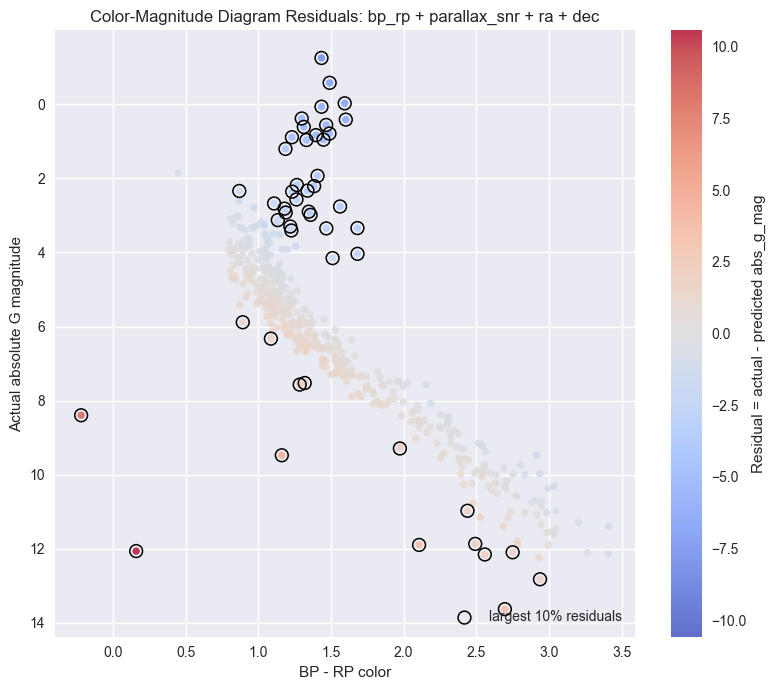

In [7]:
largest_residual_threshold = best_predictions["prediction_error_size_mag"].quantile(0.90)
large_residual_points = best_predictions[
    best_predictions["prediction_error_size_mag"] >= largest_residual_threshold
].copy()

max_abs_residual = best_predictions["residual"].abs().max()
residual_norm = TwoSlopeNorm(vmin=-max_abs_residual, vcenter=0, vmax=max_abs_residual)

fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    best_predictions["bp_rp"],
    best_predictions["actual_abs_g_mag"],
    c=best_predictions["residual"],
    cmap="coolwarm",
    norm=residual_norm,
    s=28,
    alpha=0.78,
    linewidths=0,
)

ax.scatter(
    large_residual_points["bp_rp"],
    large_residual_points["actual_abs_g_mag"],
    facecolors="none",
    edgecolors="black",
    s=85,
    linewidths=1.1,
    label="largest 10% residuals",
)

ax.invert_yaxis()
ax.set_title(f"Color-Magnitude Diagram Residuals: {best_model_name}")
ax.set_xlabel("BP - RP color")
ax.set_ylabel("Actual absolute G magnitude")
ax.legend(loc="lower right")

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Residual = actual - predicted abs_g_mag")

plt.tight_layout()
plt.show()

## 8. High-Residual Examples

Large residuals are not just mistakes to hide. They are where the model is telling us it does not understand part of the data.

The helper below assigns a cautious interpretation label. These labels are not confirmed classifications. They are starting hypotheses based on color, brightness, and parallax measurement reliability.

In [8]:
def classify_residual_source(row):
    """Return a cautious astronomy interpretation for a high-residual source."""
    if row["parallax_snr"] < 8:
        return "lower parallax SNR; target may be noisier"
    if row["bp_rp"] < 0.5 and row["actual_abs_g_mag"] > 7:
        return "blue but faint; possible white-dwarf-like outlier"
    if row["bp_rp"] > 2.5 and row["actual_abs_g_mag"] < 4:
        return "red but bright; possible giant-like outlier"
    if row["actual_abs_g_mag"] < 2:
        return "very bright for this color; possible giant or upper-main-sequence source"
    if row["bp_rp"] > 2.5:
        return "very red source; straight-line model may miss red-star curvature"
    return "main-sequence curvature or mixed stellar population"

high_residual_examples = (
    best_predictions
    .sort_values("prediction_error_size_mag", ascending=False)
    .head(12)
    .copy()
)

high_residual_examples["possible_interpretation"] = high_residual_examples.apply(
    classify_residual_source,
    axis=1,
)

high_residual_examples[
    [
        "source_id",
        "bp_rp",
        "parallax_snr",
        "actual_abs_g_mag",
        "predicted_abs_g_mag",
        "residual",
        "prediction_error_size_mag",
        "possible_interpretation",
    ]
]

,source_id,bp_rp,parallax_snr,actual_abs_g_mag,predicted_abs_g_mag,residual,prediction_error_size_mag,possible_interpretation
1078,139254388905996032,0.159437,13.347744,12.060765,1.492632,10.568133,10.568133,blue but faint; possible white-dwarf-like outlier
1427,139484629215390464,-0.219013,6.473233,8.395272,0.290649,8.104623,8.104623,lower parallax SNR; target may be noisier
1280,141420117574894080,1.434080,11.618137,-1.248268,6.253416,-7.501684,7.501684,very bright for this color; possible giant or ...
1245,138907011949915008,1.490329,11.185368,-0.577621,6.149890,-6.727511,6.727511,very bright for this color; possible giant or ...
1384,139004318728815104,1.593946,18.325787,-0.024381,6.513033,-6.537414,6.537414,very bright for this color; possible giant or ...
981,139366882688665728,1.601420,7.194200,0.415702,6.478250,-6.062548,6.062548,lower parallax SNR; target may be noisier
1345,138840594575909632,1.434197,6.478127,0.067361,5.870697,-5.803336,5.803336,lower parallax SNR; target may be noisier
1153,138947728239998976,1.466312,6.109878,0.559912,5.979628,-5.419716,5.419716,lower parallax SNR; target may be noisier
1175,139149209450248832,1.488963,149.388075,0.791668,6.020054,-5.228386,5.228386,very bright for this color; possible giant or ...
1337,141360262910325888,1.312448,17.987554,0.613111,5.791922,-5.178811,5.178811,very bright for this color; possible giant or ...


## 9. Summarize Residual Patterns

These group summaries help connect prediction errors back to astronomy.

Because `abs_g_mag` is inverted, lower values are brighter. A star with `abs_g_mag = 0` is much brighter than a star with `abs_g_mag = 10`.

In [9]:
residual_summary_table = pd.DataFrame(
    [
        {
            "region": "bright stars",
            "selection": "actual_abs_g_mag < 2",
            "rows": int((best_predictions["actual_abs_g_mag"] < 2).sum()),
            "mean_error_size_mag": best_predictions.loc[
                best_predictions["actual_abs_g_mag"] < 2,
                "prediction_error_size_mag",
            ].mean(),
            "interpretation": "Bright giants or upper-main-sequence stars can sit away from the main trend.",
        },
        {
            "region": "faint stars",
            "selection": "actual_abs_g_mag > 10",
            "rows": int((best_predictions["actual_abs_g_mag"] > 10).sum()),
            "mean_error_size_mag": best_predictions.loc[
                best_predictions["actual_abs_g_mag"] > 10,
                "prediction_error_size_mag",
            ].mean(),
            "interpretation": "Very faint objects can include lower main-sequence stars or white-dwarf-like outliers.",
        },
        {
            "region": "very red stars",
            "selection": "bp_rp > 2.5",
            "rows": int((best_predictions["bp_rp"] > 2.5).sum()),
            "mean_error_size_mag": best_predictions.loc[
                best_predictions["bp_rp"] > 2.5,
                "prediction_error_size_mag",
            ].mean(),
            "interpretation": "The red end of the main sequence is curved, so a straight line can miss it.",
        },
        {
            "region": "blue/faint outliers",
            "selection": "bp_rp < 0.5 and actual_abs_g_mag > 7",
            "rows": int(((best_predictions["bp_rp"] < 0.5) & (best_predictions["actual_abs_g_mag"] > 7)).sum()),
            "mean_error_size_mag": best_predictions.loc[
                (best_predictions["bp_rp"] < 0.5) & (best_predictions["actual_abs_g_mag"] > 7),
                "prediction_error_size_mag",
            ].mean(),
            "interpretation": "Blue but faint objects may behave unlike ordinary main-sequence stars.",
        },
        {
            "region": "lower-SNR parallaxes",
            "selection": "parallax_snr < 8",
            "rows": int((best_predictions["parallax_snr"] < 8).sum()),
            "mean_error_size_mag": best_predictions.loc[
                best_predictions["parallax_snr"] < 8,
                "prediction_error_size_mag",
            ].mean(),
            "interpretation": "Less reliable parallax can make the computed absolute magnitude noisier.",
        },
    ]
)

residual_summary_table

,region,selection,rows,mean_error_size_mag,interpretation
0,bright stars,actual_abs_g_mag < 2,16,5.064456,Bright giants or upper-main-sequence stars can...
1,faint stars,actual_abs_g_mag > 10,52,0.960476,Very faint objects can include lower main-sequ...
2,very red stars,bp_rp > 2.5,62,0.585572,"The red end of the main sequence is curved, so..."
3,blue/faint outliers,bp_rp < 0.5 and actual_abs_g_mag > 7,2,9.336378,Blue but faint objects may behave unlike ordin...
4,lower-SNR parallaxes,parallax_snr < 8,126,0.974694,Less reliable parallax can make the computed a...


## 10. Final Astronomy Summary

The comparison table shows that most of the useful signal comes from `bp_rp`. That makes physical sense because color is related to stellar temperature, and temperature is connected to luminosity for many stars.

The best model by RMSE may include `parallax_snr`, `ra`, and `dec`, but the improvement is small. That means those extra features are better interpreted as diagnostic context than as a strong physical explanation of intrinsic brightness.

The biggest failure modes appear where the HR diagram is not a single straight line: very bright stars, very faint stars, very red stars, possible white-dwarf-like objects, possible giant-like objects, and stars with less reliable parallax measurements.

Astronomy meaning: a one-line regression is a useful first model, but stars are not one uniform population. Residuals help reveal where the data contains richer structure than the model can represent.

In [10]:
output_dir_candidates = [
    Path("../data/processed"),
    Path("data/processed"),
    Path("gaia-explorer/data/processed"),
]

OUTPUT_DIR = next((path for path in output_dir_candidates if path.exists()), output_dir_candidates[0])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = OUTPUT_DIR / "gaia_day7_model_comparison.csv"
predictions_path = OUTPUT_DIR / "gaia_day7_all_model_predictions.csv"
high_residual_path = OUTPUT_DIR / "gaia_day7_high_residual_examples.csv"
residual_summary_path = OUTPUT_DIR / "gaia_day7_residual_summary.csv"

model_comparison.to_csv(comparison_path, index=False)
all_predictions_df.to_csv(predictions_path, index=False)
high_residual_examples.to_csv(high_residual_path, index=False)
residual_summary_table.to_csv(residual_summary_path, index=False)

print(f"Saved model comparison to: {comparison_path}")
print(f"Saved all model predictions to: {predictions_path}")
print(f"Saved high-residual examples to: {high_residual_path}")
print(f"Saved residual summary to: {residual_summary_path}")

Saved model comparison to: ../data/processed/gaia_day7_model_comparison.csv
Saved all model predictions to: ../data/processed/gaia_day7_all_model_predictions.csv
Saved high-residual examples to: ../data/processed/gaia_day7_high_residual_examples.csv
Saved residual summary to: ../data/processed/gaia_day7_residual_summary.csv


## Reflection Questions And Starter Answers

1. Why is a straight line too simple for the full HR diagram?

   **Starter answer:** The HR diagram contains curved sequences and multiple stellar populations. A straight line can capture the broad main trend, but it cannot bend around the lower main sequence or separate giants, white dwarfs, and unusual sources.

2. Which stellar groups might cause large residuals?

   **Starter answer:** Possible groups include bright giant-like stars, very red low-mass stars, white-dwarf-like blue/faint objects, upper-main-sequence stars, and sources with noisier parallax measurements.

3. What did multiple linear regression help reveal?

   **Starter answer:** It showed that `bp_rp` explains most of the predictable brightness pattern in this simple setup. Adding `parallax_snr`, `ra`, and `dec` changed the metrics only slightly, so the extra columns are more useful for diagnostics than for a strong physical brightness model.

4. What would be worth trying next?

   **Starter answer:** Polynomial regression could model curvature in the color-magnitude diagram. Clustering could separate stellar populations before fitting. Neural networks could learn more flexible nonlinear patterns, but they would need careful validation and interpretation.

5. Why keep residual examples instead of only keeping final metrics?

   **Starter answer:** Metrics summarize average performance, but residual examples show where the model fails. Those failures are often the most useful places to learn astronomy from the data.